In [25]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
%autoreload 2

import os
import sys
from glob import glob
import py3Dmol
import rdkit
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.set_loglevel(level = 'warning')
import logging
pil_logger = logging.getLogger('PIL')
pil_logger.setLevel(logging.INFO)  # Disable warnings output
import pickle

import molparse as mp

gmx_tools_path = r'../Gmx_Tools'   # Your path to Gmx_Tools
sys.path.append(gmx_tools_path)

import gmx_tools as gt

## Extra analysis

### Interaction energy

#### Setting up

To understand which residues of the protein play an important role, it is generally a good idea to investigate the interactions between the probes and the reisdues around the highest occupancy (and/or lowest free energy) hotspots. Luckily, the binding sites of Tar are already known and it includes residues 64 to 73 (from both chains) as well as residues 149 to 155 (form both chains too).\
If the residues are not known, you can take the highest occupancy voxel and look at all the residues within 0.5 to 0.6 nm from it (for example).

To get interaction energies from a GROMACS simulations, the interacting groups need to be specified in the MDP file as follow:\
&emsp;"energygrps &emsp; = &emsp; LIG \_\_XXX__" (with \_\_XXX__ the group interacting with the ligand LIG).\
A template MDP file is available in the 'input/extra/' directory (note: nstxtcout is set to 0 as we don't want to generate new trajectory, we want to get the interaction energies from the previous run).

We will look at the interaction between the probe (aspartate in that case, referred to as LIG in the index file) and each residue of the binding site. For example, to investigate the interaction energy between aspartate and the arginine 64 from the chain A of Tar, we will proceed as follow:\
&emsp;1 - Generate a new NDX file with System, LIG and ARG64:\
&emsp;"printf 'System\nLIG\nri 29\nname20 ARG64_A\ndel 0-17\nq\n' | gmx make_ndx -f output/system_npt.gro -n input/index.ndx -o input/extra/index_arg64_a.ndx\
&emsp;2 - Generate a new MDP file for LIG and ARG64:\
&emsp;"cp input/extra/ie_template.mdp input/extra/ie_arg64_a.mdp"\
&emsp;"sed -i 's/\_\_XXX__/ARG64_A/' input/extra/ie_arg64_a.mdp"\
&emsp;3 - Rerun the MD simulations using the previous trajectory and the new mdp:\
&emsp;"gmx grompp -f input/extra/ie_arg64_a.mdp -o output/inter_ener/ie_arg64_a"\
&emsp;"gmx mdrun -deffnm output/inter_ener/ie_arg64_a -rerun output/system_prod -nb cpu" (NOTE: calculation of interaction energy cannot be performed on GPU and has to be run on CPU instead).\
&emsp;4 - Extract short range potential energy between LIG and site of interest:\
&emsp;"printf 'LJ-SR:LIG-ARG64_A\nCoul-SR:LIG-ARG64_A\n0\n' | gmx energy -f output/inter_ener/ie_arg64_a.edr -o output/inter_ener/ie_arg64_a.xvg" (NOTE: due to the 1.2 nm energy cutoff, there is no need to select only the aspartate inside the binding site, as the short range energy between LIG and the site of interest will only consider the aspartate withing the cutoff of the site of interest).\
\
This process needs to be repeated for all the residues of the binding site (this can be easily automated using a bash script and looping over both the residue name and residue ids). We have already rerun the simulation and extracted the short range potential energy for all residues of the binding site, they are available in the 'output/inter_ener/' directory.\
Alternatively, you can create a single new index file with all the residues of the binding site as unique selection, rerun the trajectory only once and extract all the interaction energy one by one.

#### Analysis

Now that we have all the interaction energies, let's plot the results.

(array([-400., -350., -300., -250., -200., -150., -100.,  -50.,    0.,
          50.,  100.]),
 [Text(0, -400.0, '−400'),
  Text(0, -350.0, '−350'),
  Text(0, -300.0, '−300'),
  Text(0, -250.0, '−250'),
  Text(0, -200.0, '−200'),
  Text(0, -150.0, '−150'),
  Text(0, -100.0, '−100'),
  Text(0, -50.0, '−50'),
  Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100')])

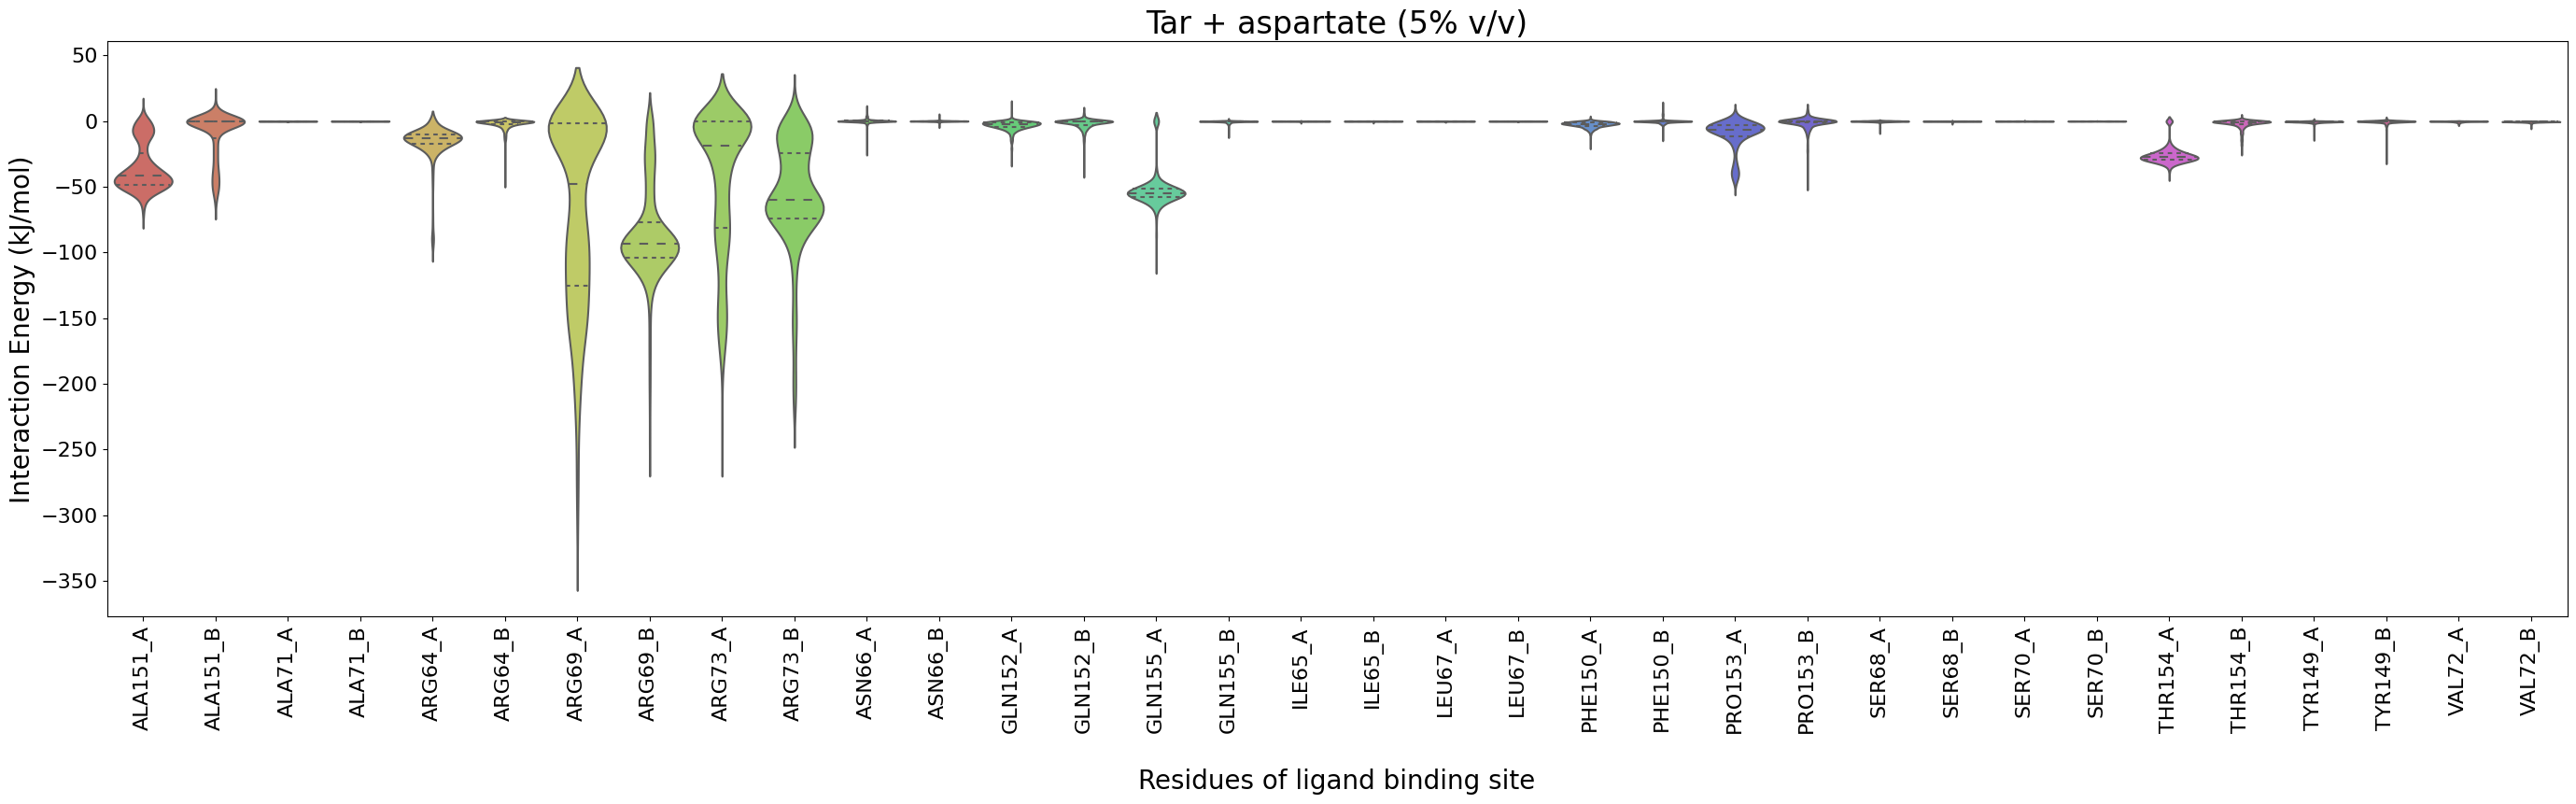

In [39]:
results={'Site':[], 'Mean':[], 'Std':[], 'Max':[], 'Min':[]}
data={'site':[], 'energy':[]}
files = sorted(glob('output/inter_ener/*.xvg'))
fig, axs = plt.subplots(figsize=(len(files),8))
palette=sns.color_palette("hls",len(files))
for file in files:
    site=file.split('inter_ener')[-1][4:-4].upper()
    xvg=gt.XVG(file)
    ie_lj=xvg.y_columns[0]
    ie_coul=xvg.y_columns[1]
    total_ie=[lj+coul for lj, coul in zip(ie_lj, ie_coul)]
    for value in total_ie:
        data['site'].append(site)
        data['energy'].append(value)
    results['Site'].append(site)
    results['Mean'].append(np.mean(total_ie))
    results['Std'].append(np.std(total_ie))
    results['Max'].append(max(total_ie))
    results['Min'].append(min(total_ie))
axs = sns.violinplot(y="energy", x="site", data=pd.DataFrame(data), scale='count', inner='quart', palette=palette)
plt.title('Tar + aspartate (5% v/v)', size=24)
plt.xlabel('\nResidues of ligand binding site', size=20)
plt.xticks(rotation=90, size=16)
plt.ylabel('Interaction Energy (kJ/mol)', size=20)
plt.yticks(size=16)

In [42]:
df=pd.DataFrame(results).sort_values(by='Mean')
df

,Site,Mean,Std,Max,Min
7,ARG69_B,-86.297527,37.684364,2.776488,-251.298592
6,ARG69_A,-70.263682,72.342051,4.469755,-320.937104
9,ARG73_B,-57.954055,43.255415,13.780552,-226.621376
14,GLN155_A,-52.798416,13.260271,0.000935,-109.226243
8,ARG73_A,-45.185682,54.584534,8.703802,-242.879305
0,ALA151_A,-35.395773,17.497401,8.679744,-72.707698
28,THR154_A,-25.884343,6.770051,0.000000,-41.790657
4,ARG64_A,-16.432133,15.148728,0.032646,-99.112551
22,PRO153_A,-10.184740,11.829019,6.979416,-50.217406
1,ALA151_B,-10.180752,17.952132,15.840990,-65.568879


As we can see, the strongest interactions involve ARG69 and ARG73.

This is the end of the tutorial, good luck with your simulations!